## DATASETS PREPARATION
___

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from matplotlib.ticker import MaxNLocator

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from collections import Counter

In [3]:
# DATASET 1
path = 'SRT2026.csv'
dfsrt = pd.read_csv(path)
print(dfsrt.info())
print(dfsrt.isnull().sum())
dfsrt.head()

<class 'pandas.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8273 non-null   str    
 1   LEVEL             8273 non-null   int64  
 2   TYPE              8273 non-null   str    
 3   DEPARTMENT        8273 non-null   str    
 4   DOB               8273 non-null   str    
 5   AGE               8273 non-null   float64
 6   GENERAL           8273 non-null   int64  
 7   TECHNICAL         8273 non-null   int64  
 8   DIGITAL           8273 non-null   int64  
 9   TOTALTRAINING     8273 non-null   int64  
 10  TURN60            8273 non-null   str    
 11  RETIREMENTYEAR    8273 non-null   int64  
 12  RETIREMENTDATE    8273 non-null   str    
 13  RETIREGROUP       8273 non-null   str    
 14  YEARS2RETIREMENT  8273 non-null   float64
dtypes: float64(2), int64(6), str(7)
memory usage: 969.6 KB
None
ID                  0
LEVEL             

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,TURN60,RETIREMENTYEAR,RETIREMENTDATE,RETIREGROUP,YEARS2RETIREMENT
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,1,0,0,1,2031-09-08,2031,2031-10-01,A (JAN-SEP),5.75
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,1,0,0,1,2025-10-11,2026,2026-10-01,B (OCT-DEC),0.75
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,0,0,0,0,2030-08-18,2030,2030-10-01,A (JAN-SEP),4.75
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,0,0,0,0,2027-07-02,2027,2027-10-01,A (JAN-SEP),1.75
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,0,0,0,0,2029-06-19,2029,2029-10-01,A (JAN-SEP),3.75


___
#### PREP A: TO INCLUDE CLUSTER NUMBERS AND LABELS INTO SRT2026.CSV

In [ ]:
# DATASET 2 - TO RE-RUN AND OBTAIN THE KM6 CLUSTER LABEL COLUMN
path = 'SRTEMPLOYEES2026A.csv'
df = pd.read_csv(path)
print(df.info())
print(df.isnull().sum())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 19026 entries, 0 to 19025
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          19026 non-null  str    
 1   LEVEL       19026 non-null  int64  
 2   TYPE        19026 non-null  str    
 3   DEPARTMENT  19026 non-null  str    
 4   DOB         19026 non-null  str    
 5   AGE         19026 non-null  int64  
 6   COURSE      15862 non-null  str    
 7   PILLAR      15862 non-null  float64
 8   GENERAL     19026 non-null  int64  
 9   TECHNICAL   19026 non-null  int64  
 10  DIGITAL     19026 non-null  int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 1.6 MB
None
ID               0
LEVEL            0
TYPE             0
DEPARTMENT       0
DOB              0
AGE              0
COURSE        3164
PILLAR        3164
GENERAL          0
TECHNICAL        0
DIGITAL          0
dtype: int64


,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,COURSE,PILLAR,GENERAL,TECHNICAL,DIGITAL
0,SRT_1,14,Governance & Support,Governor Bureau,8/9/1971,54,โครงการพัฒนาผู้บริหารระดับสูง (Crucial Convers...,1.0,1,0,0
1,SRT_2,14,Governance & Support,Governor Bureau,11/10/1965,60,การบริหารความต่อเนื่องทางธุรกิจระดับองค์กร,1.0,1,0,0
2,SRT_3,14,Governance & Support,Governor Bureau,18/8/1970,55,NaN,NaN,0,0,0
3,SRT_4,14,Governance & Support,Governor Bureau,2/7/1967,58,NaN,NaN,0,0,0
4,SRT_5,14,Governance & Support,Governor Bureau,19/6/1969,56,NaN,NaN,0,0,0


In [5]:
# FILL MISSING VALUES FOR THOSE EMPLOYEES WITHOUT TRAINING
df['COURSE'] = df['COURSE'].fillna('N/A')
df['PILLAR'] = df['PILLAR'].fillna(0).astype(int)
df[['COURSE', 'PILLAR']].isna().sum()

COURSE    0
PILLAR    0
dtype: int64

In [6]:
df.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,COURSE,PILLAR,GENERAL,TECHNICAL,DIGITAL
0,SRT_1,14,Governance & Support,Governor Bureau,8/9/1971,54,โครงการพัฒนาผู้บริหารระดับสูง (Crucial Convers...,1,1,0,0
1,SRT_2,14,Governance & Support,Governor Bureau,11/10/1965,60,การบริหารความต่อเนื่องทางธุรกิจระดับองค์กร,1,1,0,0
2,SRT_3,14,Governance & Support,Governor Bureau,18/8/1970,55,N/A,0,0,0,0
3,SRT_4,14,Governance & Support,Governor Bureau,2/7/1967,58,N/A,0,0,0,0
4,SRT_5,14,Governance & Support,Governor Bureau,19/6/1969,56,N/A,0,0,0,0


In [ ]:
# MULTISTEP PREP 1: DATASET COPY + DROP COLUMNS + GROUPBY-AGG + SUM-NEW COLUMN
data = df.copy()
data['DOB'] = pd.to_datetime(data['DOB'], format='%d/%m/%Y', errors='coerce')
data.drop(['DEPARTMENT', 'COURSE', 'PILLAR'], axis=1, inplace=True)
data = (
    data.groupby('ID', sort=False, as_index=False)
        .agg({
            'LEVEL': 'first',
            'TYPE': 'first',
            'GENERAL': 'sum',
            'TECHNICAL': 'sum',
            'DIGITAL': 'sum'
        })
)
data['TOTALTRAINING'] = data[['GENERAL', 'TECHNICAL', 'DIGITAL']].sum(axis=1)
data

,ID,LEVEL,TYPE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING
0,SRT_1,14,Governance & Support,1,0,0,1
1,SRT_2,14,Governance & Support,1,0,0,1
2,SRT_3,14,Governance & Support,0,0,0,0
3,SRT_4,14,Governance & Support,0,0,0,0
4,SRT_5,14,Governance & Support,0,0,0,0
...,...,...,...,...,...,...,...
8268,SRT_8269,8,Governance & Support,5,0,0,5
8269,SRT_8270,8,Governance & Support,3,1,0,4
8270,SRT_8271,8,Governance & Support,12,2,1,15
8271,SRT_8272,6,Governance & Support,3,2,3,8


In [ ]:
# MULTISTEP PREP 2: DATASET COPY + ONE-HOT ENCODING + CONCATENATE DATAFRAME + DROP COLUMN
t = pd.get_dummies(data['TYPE']).astype('int')
data = pd.concat([data, t], axis=1)
datamo = data.drop(['ID', 'TYPE'], axis=1)
print(f'NUMBER OF DATA ROWS: {datamo.shape[0]}')
print(f'NUMBER OF DATA COLUMNS:{datamo.shape[1]}')
datamo.head()

NUMBER OF DATA ROWS: 8273
NUMBER OF DATA COLUMNS:9


,LEVEL,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate
0,14,1,0,0,1,1,0,0,0
1,14,1,0,0,1,1,0,0,0
2,14,0,0,0,0,1,0,0,0
3,14,0,0,0,0,1,0,0,0
4,14,0,0,0,0,1,0,0,0


In [9]:
# DATAPREP: SCALING/STANDARISATION
scaler = StandardScaler()
scdata = scaler.fit_transform(datamo)
dfs = pd.DataFrame(scdata, columns=datamo.columns)
dfs.head().round(3)

,LEVEL,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate
0,4.616,0.224,-0.672,-0.248,-0.301,3.645,-1.068,-0.798,-0.089
1,4.616,0.224,-0.672,-0.248,-0.301,3.645,-1.068,-0.798,-0.089
2,4.616,-0.316,-0.672,-0.248,-0.628,3.645,-1.068,-0.798,-0.089
3,4.616,-0.316,-0.672,-0.248,-0.628,3.645,-1.068,-0.798,-0.089
4,4.616,-0.316,-0.672,-0.248,-0.628,3.645,-1.068,-0.798,-0.089


CLUSTER LABEL COUNT:Counter({np.int32(3): 3856, np.int32(0): 3127, np.int32(1): 560, np.int32(5): 428, np.int32(2): 237, np.int32(4): 65})



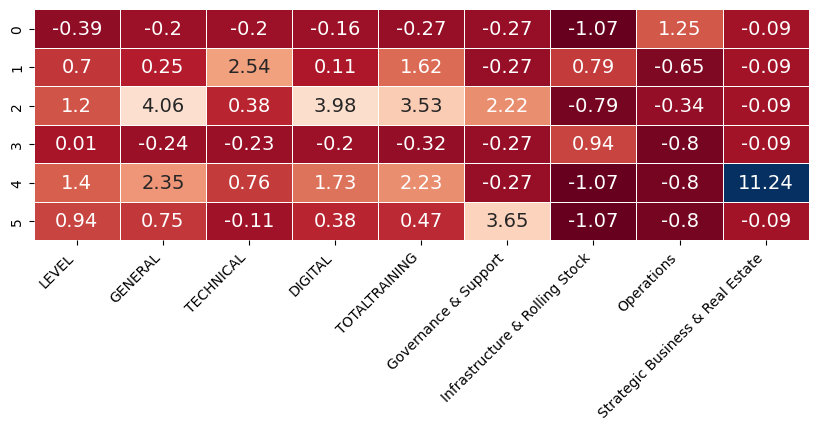

In [ ]:
# MODEL REFIT + LABEL COUNT + CLUSTER CENTRES HEATMAP
km6 = KMeans(n_clusters=6, n_init=10, random_state=1234).fit(dfs)
print(f'CLUSTER LABEL COUNT:{Counter(km6.labels_)}\n')

plt.figure(figsize=(10, 3))
cc6 = pd.DataFrame(np.round(km6.cluster_centers_, 2), columns=dfs.columns)
sns.heatmap(cc6, annot=True, cmap='RdBu', fmt='g', linewidths=0.5, annot_kws={'size': 14}, cbar=False)
plt.xticks(rotation=45, ha='right');
#INTERPRETATION: THIS CLUSTERING HAS WITHOUT THE 'AGE' COLUMN.
# CLUSTER 0: Strategic Business & Real Estate Leaders
# CLUSTER 1: Specialized Technical Field Experts
# CLUSTER 2: Essential Infrastructure Field Crew
# CLUSTER 3: Advanced Governance & Support Specialists
# CLUSTER 4: Governance & Support Professionals
# CLUSTER 5: Core Frontline Operations Staff

In [11]:
# ATTACH CLUSTERS BACK ONTO 'SRTEMPLOYEES2026_EXPANDED.csv'
clabels = {
    0: 'Core Frontline Operations Staff',
    1: 'Specialized Technical Field Experts',
    2: 'Advanced Governance & Support Specialists',
    3: 'Essential Infrastructure Field Crew',
    4: 'Strategic Business & Real Estate Leaders',
    5: 'Governance & Support Professionals'
}
data['CLUSTERNUM'] = km6.labels_
dfsrt['CLUSTERNUM'] = data['CLUSTERNUM']
dfsrt['CLUSTER'] = data['CLUSTERNUM'].map(clabels)
print(f'VALIDATION: {dfsrt.groupby('ID')['CLUSTER'].nunique().max()}')
# 1 → OK (VALIDATE CLUSTER CONSISTENCY)
dfsrt.head()

VALIDATION: 1


,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,TURN60,RETIREMENTYEAR,RETIREMENTDATE,RETIREGROUP,YEARS2RETIREMENT,CLUSTERNUM,CLUSTER
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,1,0,0,1,2031-09-08,2031,2031-10-01,A (JAN-SEP),5.75,5,Governance & Support Professionals
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,1,0,0,1,2025-10-11,2026,2026-10-01,B (OCT-DEC),0.75,5,Governance & Support Professionals
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,0,0,0,0,2030-08-18,2030,2030-10-01,A (JAN-SEP),4.75,5,Governance & Support Professionals
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,0,0,0,0,2027-07-02,2027,2027-10-01,A (JAN-SEP),1.75,5,Governance & Support Professionals
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,0,0,0,0,2029-06-19,2029,2029-10-01,A (JAN-SEP),3.75,5,Governance & Support Professionals


In [12]:
# VALIDATION 1
print(dfsrt['CLUSTER'].value_counts())
pd.crosstab(dfsrt['CLUSTERNUM'], dfsrt['TYPE'])

CLUSTER
Essential Infrastructure Field Crew          3856
Core Frontline Operations Staff              3127
Specialized Technical Field Experts           560
Governance & Support Professionals            428
Advanced Governance & Support Specialists     237
Strategic Business & Real Estate Leaders       65
Name: count, dtype: int64


TYPE,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate
CLUSTERNUM,,,,
0,0,0,3127,0
1,0,519,41,0
2,151,33,53,0
3,0,3856,0,0
4,0,0,0,65
5,428,0,0,0


In [13]:
# VALIDATION 2
print(dfsrt.groupby('CLUSTERNUM')[['LEVEL', 'GENERAL', 'TECHNICAL', 'DIGITAL', 'TOTALTRAINING']].mean().round(2))
print()
print(pd.crosstab(dfsrt['CLUSTERNUM'], dfsrt['TYPE']))

            LEVEL  GENERAL  TECHNICAL  DIGITAL  TOTALTRAINING
CLUSTERNUM                                                   
0            4.60     0.21       0.83     0.05           1.09
1            6.65     1.06       5.59     0.23           6.88
2            7.59     8.11       1.83     2.76          12.70
3            5.37     0.13       0.77     0.03           0.93
4            7.97     4.94       2.49     1.29           8.72
5            7.11     1.97       0.98     0.41           3.36

TYPE        Governance & Support  Infrastructure & Rolling Stock  Operations  \
CLUSTERNUM                                                                     
0                              0                               0        3127   
1                              0                             519          41   
2                            151                              33          53   
3                              0                            3856           0   
4                      

In [14]:
# UPDATED dfsrt
print(dfsrt.info())
dfsrt.head()

<class 'pandas.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8273 non-null   str    
 1   LEVEL             8273 non-null   int64  
 2   TYPE              8273 non-null   str    
 3   DEPARTMENT        8273 non-null   str    
 4   DOB               8273 non-null   str    
 5   AGE               8273 non-null   float64
 6   GENERAL           8273 non-null   int64  
 7   TECHNICAL         8273 non-null   int64  
 8   DIGITAL           8273 non-null   int64  
 9   TOTALTRAINING     8273 non-null   int64  
 10  TURN60            8273 non-null   str    
 11  RETIREMENTYEAR    8273 non-null   int64  
 12  RETIREMENTDATE    8273 non-null   str    
 13  RETIREGROUP       8273 non-null   str    
 14  YEARS2RETIREMENT  8273 non-null   float64
 15  CLUSTERNUM        8273 non-null   int32  
 16  CLUSTER           8273 non-null   str    
dtypes: flo

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,TURN60,RETIREMENTYEAR,RETIREMENTDATE,RETIREGROUP,YEARS2RETIREMENT,CLUSTERNUM,CLUSTER
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,1,0,0,1,2031-09-08,2031,2031-10-01,A (JAN-SEP),5.75,5,Governance & Support Professionals
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,1,0,0,1,2025-10-11,2026,2026-10-01,B (OCT-DEC),0.75,5,Governance & Support Professionals
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,0,0,0,0,2030-08-18,2030,2030-10-01,A (JAN-SEP),4.75,5,Governance & Support Professionals
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,0,0,0,0,2027-07-02,2027,2027-10-01,A (JAN-SEP),1.75,5,Governance & Support Professionals
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,0,0,0,0,2029-06-19,2029,2029-10-01,A (JAN-SEP),3.75,5,Governance & Support Professionals


___
#### PREP B: TO INCLUDE HIRE PROFILE BASED ON TYPE & LEVEL
REASON: In order to assign Bloom's baseline scores, one of five profiles per agent (RTS Graduate, General Vocation / Certificate, Engineer, General Hire Bachelor+, Basic Education). This can be derived from TYPE & LEVEL using a mapping rule since no direct hire-profile field was collected. Mapping applied per institutional rules shown below. Two anomalous Strategic Level 2 records assigned 'NONE'.

MAPPING:

* Infrastructure & Rolling Stock
    * LEVEL 1–3   → Basic Education
    * LEVEL 4     → Gen Vocational Certificate
    * LEVEL 5     → RTS Graduate
    * LEVEL 6+    → Engineer

* Operations
    * LEVEL 1–3   → Basic Education
    * LEVEL 4     → Gen Vocational Certificate
    * LEVEL 5     → RTS Graduate
    * LEVEL 6+    → General Hire (Bachelors+)

* Governance & Support
    * LEVEL 1–5   → Gen Vocational Certificate
    * LEVEL 6+    → General Hire (Bachelors+)

* Strategic Business & Real Estate
    * LEVEL 1–5   → No hires for these levels
    * LEVEL 6+    → General Hire (Bachelors+)

In [32]:
# ASSIGN HIREPROFILE FROM TYPE × LEVEL MAPPING
def hp(row):
    t, l = row['TYPE'], row['LEVEL']

    if t == 'Infrastructure & Rolling Stock':
        if l <= 3:   return 'Basic Education'
        elif l == 4: return 'Vocational Diploma & Certificate'
        elif l == 5: return 'RTS Graduate'
        else:        return 'Engineer'

    elif t == 'Operations':
        if l <= 3:   return 'Basic Education'
        elif l == 4: return 'Vocational Diploma & Certificate'
        elif l == 5: return 'RTS Graduate'
        else:        return 'General Hire (Bachelors+)'

    elif t == 'Governance & Support':
        if l <= 5:   return 'Vocational Diploma & Certificate'
        else:        return 'General Hire (Bachelors+)'

    elif t == 'Strategic Business & Real Estate':
        if l <= 5:   return 'Legacy Hires'
        else:        return 'General Hire (Bachelors+)'

    return None

dfsrt['HIREPROFILE'] = dfsrt.apply(hp, axis=1)
dfsrt.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,TURN60,RETIREMENTYEAR,RETIREMENTDATE,RETIREGROUP,YEARS2RETIREMENT,CLUSTERNUM,CLUSTER,HIREPROFILE
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,1,0,0,1,2031-09-08,2031,2031-10-01,A (JAN-SEP),5.75,5,Governance & Support Professionals,General Hire (Bachelors+)
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,1,0,0,1,2025-10-11,2026,2026-10-01,B (OCT-DEC),0.75,5,Governance & Support Professionals,General Hire (Bachelors+)
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,0,0,0,0,2030-08-18,2030,2030-10-01,A (JAN-SEP),4.75,5,Governance & Support Professionals,General Hire (Bachelors+)
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,0,0,0,0,2027-07-02,2027,2027-10-01,A (JAN-SEP),1.75,5,Governance & Support Professionals,General Hire (Bachelors+)
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,0,0,0,0,2029-06-19,2029,2029-10-01,A (JAN-SEP),3.75,5,Governance & Support Professionals,General Hire (Bachelors+)


In [33]:
# VALIDATION
print(dfsrt['HIREPROFILE'].value_counts(dropna=False))
print('\nTYPE & HIREPROFILE crosstab:')
pd.crosstab(dfsrt['TYPE'], dfsrt['HIREPROFILE'], dropna=False)

HIREPROFILE
Engineer                            2468
General Hire (Bachelors+)           2117
RTS Graduate                        1522
Basic Education                     1362
Vocational Diploma & Certificate     802
Legacy Hires                           2
Name: count, dtype: int64

TYPE & HIREPROFILE crosstab:


HIREPROFILE,Basic Education,Engineer,General Hire (Bachelors+),Legacy Hires,RTS Graduate,Vocational Diploma & Certificate
TYPE,,,,,,
Governance & Support,0,0,550,0,0,29
Infrastructure & Rolling Stock,406,2468,0,0,1199,335
Operations,956,0,1504,0,323,438
Strategic Business & Real Estate,0,0,63,2,0,0


In [34]:
# QUICK CHECK
print(dfsrt.info())
print(dfsrt.isnull().sum())
dfsrt.head()

<class 'pandas.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8273 non-null   str    
 1   LEVEL             8273 non-null   int64  
 2   TYPE              8273 non-null   str    
 3   DEPARTMENT        8273 non-null   str    
 4   DOB               8273 non-null   str    
 5   AGE               8273 non-null   float64
 6   GENERAL           8273 non-null   int64  
 7   TECHNICAL         8273 non-null   int64  
 8   DIGITAL           8273 non-null   int64  
 9   TOTALTRAINING     8273 non-null   int64  
 10  TURN60            8273 non-null   str    
 11  RETIREMENTYEAR    8273 non-null   int64  
 12  RETIREMENTDATE    8273 non-null   str    
 13  RETIREGROUP       8273 non-null   str    
 14  YEARS2RETIREMENT  8273 non-null   float64
 15  CLUSTERNUM        8273 non-null   int32  
 16  CLUSTER           8273 non-null   str    
 17  HIREPR

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,TURN60,RETIREMENTYEAR,RETIREMENTDATE,RETIREGROUP,YEARS2RETIREMENT,CLUSTERNUM,CLUSTER,HIREPROFILE
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,1,0,0,1,2031-09-08,2031,2031-10-01,A (JAN-SEP),5.75,5,Governance & Support Professionals,General Hire (Bachelors+)
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,1,0,0,1,2025-10-11,2026,2026-10-01,B (OCT-DEC),0.75,5,Governance & Support Professionals,General Hire (Bachelors+)
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,0,0,0,0,2030-08-18,2030,2030-10-01,A (JAN-SEP),4.75,5,Governance & Support Professionals,General Hire (Bachelors+)
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,0,0,0,0,2027-07-02,2027,2027-10-01,A (JAN-SEP),1.75,5,Governance & Support Professionals,General Hire (Bachelors+)
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,0,0,0,0,2029-06-19,2029,2029-10-01,A (JAN-SEP),3.75,5,Governance & Support Professionals,General Hire (Bachelors+)


In [35]:
# EXPORT HIRE PROFILE DATASET IN CSV FORMAT
dest = 'SRT2026HP.csv'
dfsrt.to_csv(dest, index=False)
print(f'EXPORTED FILE: {dest}')

EXPORTED FILE: SRT2026HP.csv


___
#### PREP C: RETIREMENT SCHEDULE AGGREGATE
* A .csv standalone file for the AnyLogic event queue based on the information from the SRT2026.csv file.
* It is a year-by-year counts by TYPE from 2027–2060. In other words, this is a groupby on the RETIREMENTYEAR and TYPE columns.

In [36]:
# BUILD RETIREMENT SCHEDULE AGGREGATE (2027–2060)
sch = (
    dfsrt[dfsrt['RETIREMENTYEAR'].between(2027, 2060)]
    .groupby(['RETIREMENTYEAR', 'TYPE'])
    .size()
    .unstack(fill_value=0)
    .reindex(range(2027, 2061), fill_value=0)
)
sch['TOTAL'] = sch.sum(axis=1)
sch.index.name = 'YEAR'

print(f'YEARS(PERIOD): {sch.index.min()} – {sch.index.max()}')
print(f'TOTAL RETIREMENTS SCHEDULED: {sch["TOTAL"].sum():,}')
sch.head(10)

YEARS(PERIOD): 2027 – 2060
TOTAL RETIREMENTS SCHEDULED: 7,882


TYPE,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate,TOTAL
YEAR,,,,,
2027,14,142,146,1,303
2028,16,150,127,0,293
2029,19,155,147,3,324
2030,15,113,133,1,262
2031,31,138,134,2,305
2032,23,102,139,1,265
2033,15,137,112,3,267
2034,26,138,123,4,291
2035,38,162,151,6,357


In [30]:
# EXPORT HIRE PROFILE DATASET IN CSV FORMAT
dest = 'SRT2026RS.csv'
sch.to_csv(dest, index=False)
print(f'EXPORTED FILE: {dest}')

EXPORTED FILE: SRT2026RS.csv


In [37]:
# QUICK CHECK
path = 'SRT2026RS.csv'
test = pd.read_csv(path)
print(test.info())
print(test.isnull().sum())
test.head()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Governance & Support              34 non-null     int64
 1   Infrastructure & Rolling Stock    34 non-null     int64
 2   Operations                        34 non-null     int64
 3   Strategic Business & Real Estate  34 non-null     int64
 4   TOTAL                             34 non-null     int64
dtypes: int64(5)
memory usage: 1.5 KB
None
Governance & Support                0
Infrastructure & Rolling Stock      0
Operations                          0
Strategic Business & Real Estate    0
TOTAL                               0
dtype: int64


,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate,TOTAL
0,14,142,146,1,303
1,16,150,127,0,293
2,19,155,147,3,324
3,15,113,133,1,262
4,31,138,134,2,305


___
### SKILL BASELINE LAYER

In [48]:
# BLOOM'S BASELINE SCORES (COG, PSY, AFF) PER HIRE PROFILE × SKILL CATEGORY
bb = {
    'Basic Education': {
        'BM':  {'COG': 1.5, 'PSY': 1.5, 'AFF': 2.0},
        'TD':  {'COG': 1.5, 'PSY': 1.0, 'AFF': 1.5},
        'EI':  {'COG': 1.5, 'PSY': 2.0, 'AFF': 2.0},
        'SSG': {'COG': 2.0, 'PSY': 1.5, 'AFF': 2.0},
    },
    'Vocational Diploma & Certificate': {
        'BM':  {'COG': 2.0, 'PSY': 1.5, 'AFF': 2.0},
        'TD':  {'COG': 2.5, 'PSY': 2.0, 'AFF': 2.0},
        'EI':  {'COG': 2.5, 'PSY': 2.5, 'AFF': 2.5},
        'SSG': {'COG': 2.5, 'PSY': 2.0, 'AFF': 2.5},
    },
    'RTS Graduate': {
        'BM':  {'COG': 2.5, 'PSY': 2.0, 'AFF': 2.5},
        'TD':  {'COG': 3.0, 'PSY': 2.5, 'AFF': 2.5},
        'EI':  {'COG': 3.5, 'PSY': 3.0, 'AFF': 3.0},
        'SSG': {'COG': 2.5, 'PSY': 2.0, 'AFF': 2.5},
    },
    'General Hire (Bachelors+)': {
        'BM':  {'COG': 3.0, 'PSY': 1.0, 'AFF': 2.0},
        'TD':  {'COG': 3.0, 'PSY': 1.5, 'AFF': 2.5},
        'EI':  {'COG': 2.0, 'PSY': 1.0, 'AFF': 1.5},
        'SSG': {'COG': 3.0, 'PSY': 2.5, 'AFF': 3.0},
    },
    'Engineer': {
        'BM':  {'COG': 3.5, 'PSY': 1.5, 'AFF': 3.5},
        'TD':  {'COG': 4.0, 'PSY': 2.0, 'AFF': 3.5},
        'EI':  {'COG': 4.0, 'PSY': 1.5, 'AFF': 4.0},
        'SSG': {'COG': 3.0, 'PSY': 2.5, 'AFF': 3.5},
    }
}

In [49]:
# COMPOSITE WEIGHTS (COG, PSY, AFF) PER HIRE PROFILE × SKILL CATEGORY
bw = {
    'Basic Education': {
        'BM':  {'COG': 0.30, 'PSY': 0.30, 'AFF': 0.40},
        'TD':  {'COG': 0.30, 'PSY': 0.35, 'AFF': 0.35},
        'EI':  {'COG': 0.25, 'PSY': 0.55, 'AFF': 0.20},
        'SSG': {'COG': 0.25, 'PSY': 0.30, 'AFF': 0.45},
    },
    'Vocational Diploma & Certificate': {
        'BM':  {'COG': 0.40, 'PSY': 0.20, 'AFF': 0.40},
        'TD':  {'COG': 0.35, 'PSY': 0.35, 'AFF': 0.30},
        'EI':  {'COG': 0.30, 'PSY': 0.50, 'AFF': 0.20},
        'SSG': {'COG': 0.30, 'PSY': 0.25, 'AFF': 0.45},
    },
    'RTS Graduate': {
        'BM':  {'COG': 0.40, 'PSY': 0.20, 'AFF': 0.40},
        'TD':  {'COG': 0.40, 'PSY': 0.30, 'AFF': 0.30},
        'EI':  {'COG': 0.30, 'PSY': 0.50, 'AFF': 0.20},
        'SSG': {'COG': 0.30, 'PSY': 0.20, 'AFF': 0.50},
    },
    'General Hire (Bachelors+)': {
        'BM':  {'COG': 0.50, 'PSY': 0.10, 'AFF': 0.40},
        'TD':  {'COG': 0.50, 'PSY': 0.15, 'AFF': 0.35},
        'EI':  {'COG': 0.45, 'PSY': 0.20, 'AFF': 0.35},
        'SSG': {'COG': 0.45, 'PSY': 0.10, 'AFF': 0.45},
    },
    'Engineer': {
        'BM':  {'COG': 0.50, 'PSY': 0.10, 'AFF': 0.40},
        'TD':  {'COG': 0.50, 'PSY': 0.20, 'AFF': 0.30},
        'EI':  {'COG': 0.50, 'PSY': 0.30, 'AFF': 0.20},
        'SSG': {'COG': 0.40, 'PSY': 0.10, 'AFF': 0.50},
    }
}

In [ ]:
# COMPUTE COMPOSITE SCORES - FOUR SCORES PER AGENT
# FORMULA: COMPOSITE = COG*wCOG + PSY*wPSY + AFF*wAFF
def cc(row):
    profile = row['HIREPROFILE']
    if profile == 'Legacy Hires':
        return pd.Series({
            'BLOOMBM':  np.nan,
            'BLOOMTD':  np.nan,
            'BLOOMEI':  np.nan,
            'BLOOMSSG': np.nan,
        })

    scores  = bb[profile]
    weights = bw[profile]

    result = {}
    for cat in ['BM', 'TD', 'EI', 'SSG']:
        s = scores[cat]
        w = weights[cat]
        result[f'BLOOM{cat}'] = round((s['COG'] * w['COG']) + (s['PSY'] * w['PSY']) + (s['AFF'] * w['AFF']), 4)
    return pd.Series(result)

dfsrt[['BLOOMBM', 'BLOOMTD', 'BLOOMEI', 'BLOOMSSG']] = dfsrt.apply(cc, axis=1)

In [51]:
# VALIDATION
print('==== BLOOM SCORE NULL CHECK ====')
print(dfsrt[['BLOOMBM','BLOOMTD','BLOOMEI','BLOOMSSG']].isna().sum())

print('\n==== COMPOSITE SCORE RANGE (1.0 - 5.0) ====')
print(dfsrt[['BLOOMBM','BLOOMTD','BLOOMEI','BLOOMSSG']].describe().round(3))

print('\n==== MEAN COMPOSITE BY HIREPROFILE ====')
print(dfsrt.groupby('HIREPROFILE')[['BLOOMBM','BLOOMTD','BLOOMEI','BLOOMSSG']].mean().round(2))

print('\n==== MEAN COMPOSITE BY CLUSTER ====')
print(dfsrt.groupby('CLUSTER')[['BLOOMBM','BLOOMTD','BLOOMEI','BLOOMSSG']].mean().round(3))

==== BLOOM SCORE NULL CHECK ====
BLOOMBM     2
BLOOMTD     2
BLOOMEI     2
BLOOMSSG    2
dtype: int64

==== COMPOSITE SCORE RANGE (1.0 - 5.0) ====
        BLOOMBM   BLOOMTD   BLOOMEI  BLOOMSSG
count  8271.000  8271.000  8271.000  8271.000
mean      2.505     2.621     2.517     2.686
std       0.579     0.709     0.711     0.486
min       1.700     1.325     1.625     1.850
25%       1.900     2.175     1.625     2.375
50%       2.400     2.600     2.500     2.950
75%       3.300     3.450     3.250     3.200
max       3.300     3.450     3.250     3.200

==== MEAN COMPOSITE BY HIREPROFILE ====
                                  BLOOMBM  BLOOMTD  BLOOMEI  BLOOMSSG
HIREPROFILE                                                          
Basic Education                       1.7     1.32     1.88      1.85
Engineer                              3.3     3.45     3.25      3.20
General Hire (Bachelors+)             2.4     2.60     1.62      2.95
Legacy Hires                          NaN      N

In [52]:
dfsrt.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,...,RETIREMENTDATE,RETIREGROUP,YEARS2RETIREMENT,CLUSTERNUM,CLUSTER,HIREPROFILE,BLOOMBM,BLOOMTD,BLOOMEI,BLOOMSSG
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,1,0,0,1,...,2031-10-01,A (JAN-SEP),5.75,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,1,0,0,1,...,2026-10-01,B (OCT-DEC),0.75,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,0,0,0,0,...,2030-10-01,A (JAN-SEP),4.75,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,0,0,0,0,...,2027-10-01,A (JAN-SEP),1.75,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,0,0,0,0,...,2029-10-01,A (JAN-SEP),3.75,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95


In [53]:
# EXPORT THE ENRICHED DATASET
colorder = [
    'ID', 'LEVEL', 'TYPE', 'DEPARTMENT',
    'DOB', 'AGE', 'TURN60',
    'RETIREMENTYEAR', 'RETIREMENTDATE', 'RETIREGROUP', 'YEARS2RETIREMENT',
    'GENERAL', 'TECHNICAL', 'DIGITAL', 'TOTALTRAINING',
    'CLUSTERNUM', 'CLUSTER', 'HIREPROFILE',
    'BLOOMBM', 'BLOOMTD', 'BLOOMEI', 'BLOOMSSG'
]

dfsrt = dfsrt[colorder]
dest = 'SRT2026HPBLOOM.csv'
dfsrt.to_csv(dest, index=False)
print(f'EXPORTED FILE: {dest}')
print(f'ROWS: {len(dfsrt):,}')
print(f'COLUMNS: {len(dfsrt.columns)}')
print(f'COLUMN LIST: {list(dfsrt.columns)}')

EXPORTED FILE: SRT2026HPBLOOM.csv
ROWS: 8,273
COLUMNS: 22
COLUMN LIST: ['ID', 'LEVEL', 'TYPE', 'DEPARTMENT', 'DOB', 'AGE', 'TURN60', 'RETIREMENTYEAR', 'RETIREMENTDATE', 'RETIREGROUP', 'YEARS2RETIREMENT', 'GENERAL', 'TECHNICAL', 'DIGITAL', 'TOTALTRAINING', 'CLUSTERNUM', 'CLUSTER', 'HIREPROFILE', 'BLOOMBM', 'BLOOMTD', 'BLOOMEI', 'BLOOMSSG']


___
### SKILL GROWTH ENGINE
To define and export the parameters for the growth engine:
* Power Law exponent b values by hire profile and Bloom's domain
* Senior threshold definitions per cluster (what counts as a "Senior" for the G_Mentor ratio calculation)
* Initial Senior-to-Junior ratios per cluster at baseline year 2026

In [3]:
path = 'SRT2026HPBLOOM.csv'
dfsrt = pd.read_csv(path)
print(dfsrt.info())
print(dfsrt.isnull().sum())
dfsrt.head()

<class 'pandas.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8273 non-null   str    
 1   LEVEL             8273 non-null   int64  
 2   TYPE              8273 non-null   str    
 3   DEPARTMENT        8273 non-null   str    
 4   DOB               8273 non-null   str    
 5   AGE               8273 non-null   float64
 6   TURN60            8273 non-null   str    
 7   RETIREMENTYEAR    8273 non-null   int64  
 8   RETIREMENTDATE    8273 non-null   str    
 9   RETIREGROUP       8273 non-null   str    
 10  YEARS2RETIREMENT  8273 non-null   float64
 11  GENERAL           8273 non-null   int64  
 12  TECHNICAL         8273 non-null   int64  
 13  DIGITAL           8273 non-null   int64  
 14  TOTALTRAINING     8273 non-null   int64  
 15  CLUSTERNUM        8273 non-null   int64  
 16  CLUSTER           8273 non-null   str    
 17  HIREPR

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,TURN60,RETIREMENTYEAR,RETIREMENTDATE,RETIREGROUP,...,TECHNICAL,DIGITAL,TOTALTRAINING,CLUSTERNUM,CLUSTER,HIREPROFILE,BLOOMBM,BLOOMTD,BLOOMEI,BLOOMSSG
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,2031-09-08,2031,2031-10-01,A (JAN-SEP),...,0,0,1,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,2025-10-11,2026,2026-10-01,B (OCT-DEC),...,0,0,1,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,2030-08-18,2030,2030-10-01,A (JAN-SEP),...,0,0,0,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,2027-07-02,2027,2027-10-01,A (JAN-SEP),...,0,0,0,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,2029-06-19,2029,2029-10-01,A (JAN-SEP),...,0,0,0,5,Governance & Support Professionals,General Hire (Bachelors+),2.4,2.6,1.625,2.95


In [7]:
# SENIOR THRESHOLD DIAGNOSTIC
st = {0: 6, 1: 7, 2: 7, 3: 6, 4: 8, 5: 7}
dfsrt['SENIORINTI'] = dfsrt.apply(lambda row: int(row['LEVEL'] >= st[row['CLUSTERNUM']]), axis=1)

summary = dfsrt.groupby('CLUSTERNUM').agg(
    CLUSTER       = ('CLUSTER', 'first'),
    TOTAL         = ('ID', 'count'),
    SENIORS       = ('SENIORINTI', 'sum'),
).assign(
    JUNIORS       = lambda x: x['TOTAL'] - x['SENIORS'],
    SENIORRATIO  = lambda x: (x['SENIORS'] / x['TOTAL']).round(3),
    GMENTORINIT  = lambda x: (x['SENIORS'] / x['JUNIORS']).clip(upper=1.0).round(3)
)
summary

,CLUSTER,TOTAL,SENIORS,JUNIORS,SENIORRATIO,GMENTORINIT
CLUSTERNUM,,,,,,
0,Core Frontline Operations Staff,3127,1415,1712,0.453,0.827
1,Specialized Technical Field Experts,560,224,336,0.400,0.667
2,Advanced Governance & Support Specialists,237,136,101,0.574,1.000
3,Essential Infrastructure Field Crew,3856,2029,1827,0.526,1.000
4,Strategic Business & Real Estate Leaders,65,42,23,0.646,1.000
5,Governance & Support Professionals,428,187,241,0.437,0.776


In [5]:
print(summary.to_string())

                                              CLUSTER  TOTAL  SENIORS  JUNIORS  SENIORRATIO  GMENTORINIT
CLUSTERNUM                                                                                              
0                     Core Frontline Operations Staff   3127     1415     1712        0.453        0.827
1                 Specialized Technical Field Experts    560      224      336        0.400        0.667
2           Advanced Governance & Support Specialists    237      136      101        0.574        1.000
3                 Essential Infrastructure Field Crew   3856     2029     1827        0.526        1.000
4            Strategic Business & Real Estate Leaders     65       42       23        0.646        1.000
5                  Governance & Support Professionals    428      187      241        0.437        0.776


In [9]:
import json

clookup = {
    'seniorlevelthresholds': {
        0: 6,
        1: 7,
        2: 7,
        3: 6,
        4: 8,
        5: 7
    },
    'gmentorbaseline': {int(k): round(float(v), 3) for k, v in summary['GMENTORINIT'].items()},
    'bexponents': {
        'Basic Education': {'BM': 0.45, 'TD': 0.40, 'EI': 0.55, 'SSG': 0.45},
        'Vocational Diploma & Certificate': {'BM': 0.50, 'TD': 0.55, 'EI': 0.60, 'SSG': 0.50},
        'RTS Graduate': {'BM': 0.55, 'TD': 0.60, 'EI': 0.70, 'SSG': 0.55},
        'General Hire (Bachelors+)': {'BM': 0.65, 'TD': 0.60, 'EI': 0.45, 'SSG': 0.65},
        'Engineer': {'BM': 0.70, 'TD': 0.65, 'EI': 0.65, 'SSG': 0.60}
    },
    'skillbasedseniorthreshold': 4.0,
    'seniorrule': 'LEVEL-based at initialisation (2026); skill-based (composite >= 4.0) from 2027 onwards',
    'montecarlosensitivity': {
        'bperturbation': '±50% of baseline b per hire profile per category',
        'entryscoreperturbation': '±0.5 per composite score'
    }
}
dest = 'SRT2026CLUSTERLOOKUP.json'
with open(dest, 'w') as f:
    json.dump(clookup, f, indent=4)

print(json.dumps(clookup, indent=4))
print(f'\nFILE EXPORTED: {dest}')

{
    "seniorlevelthresholds": {
        "0": 6,
        "1": 7,
        "2": 7,
        "3": 6,
        "4": 8,
        "5": 7
    },
    "gmentorbaseline": {
        "0": 0.827,
        "1": 0.667,
        "2": 1.0,
        "3": 1.0,
        "4": 1.0,
        "5": 0.776
    },
    "bexponents": {
        "Basic Education": {
            "BM": 0.45,
            "TD": 0.4,
            "EI": 0.55,
            "SSG": 0.45
        },
        "Vocational Diploma & Certificate": {
            "BM": 0.5,
            "TD": 0.55,
            "EI": 0.6,
            "SSG": 0.5
        },
        "RTS Graduate": {
            "BM": 0.55,
            "TD": 0.6,
            "EI": 0.7,
            "SSG": 0.55
        },
        "General Hire (Bachelors+)": {
            "BM": 0.65,
            "TD": 0.6,
            "EI": 0.45,
            "SSG": 0.65
        },
        "Engineer": {
            "BM": 0.7,
            "TD": 0.65,
            "EI": 0.65,
            "SSG": 0.6
        }
    },
    "s

___
**END**